In [9]:
# Cell 1: Import necessary libraries
# We import numpy for numerical operations and matplotlib for plotting.
# If you don't have these, you can install them in your terminal:
# pip install numpy matplotlib

import math
import numpy as np
import matplotlib.pyplot as plt  # Alias

print("Libraries imported successfully!")

Libraries imported successfully!


#### Example 1: Petroleum Engineering - Gas Compressibility Factor (z-factor)

 -  Formula: A simplified correlation for z-factor based on pseudo-reduced pressure (P_pr).
 -  In reality, this is more `complex`, but this demonstrates the logic.

In [2]:
def calculate_z_factor(P_pr):
    """
    Calculates a simplified gas compressibility factor (z-factor)
    based on pseudo-reduced pressure. This is a hypothetical correlation
    for educational purposes only.

    Args:
        P_pr (float): Pseudo-reduced pressure.

    Returns:
        float: Approximate z-factor.
    """
    if P_pr < 2.0:
        z = 1.0 - 0.1 * P_pr
    elif 2.0 <= P_pr <= 5.0:
        z = 0.9 - 0.05 * (P_pr - 2)
    else:                     # P_pr > 5.0
        z = 0.85 + 0.02 * (P_pr - 5)
    return z

# Example usage
pressure_input = 3.5
z_factor = calculate_z_factor(pressure_input)
print(f"For a pseudo-reduced pressure of {pressure_input}, the simplified z-factor is approximately: {z_factor:.3f}")

# Testing the function with different pressures
print("\nTesting with different pressures:")
for p in [1.0, 3.0, 6.0]:
    print(f"P_pr = {p} -> z = {calculate_z_factor(p):.3f}")

For a pseudo-reduced pressure of 3.5, the simplified z-factor is approximately: 0.825

Testing with different pressures:
P_pr = 1.0 -> z = 0.900
P_pr = 3.0 -> z = 0.850
P_pr = 6.0 -> z = 0.870


#### Example 2: Petroleum Engineering - Oil Formation Volume Factor (Bo)

 -  Formula: A simplified Standing's correlation for Bo (for undersaturated oil).
 -  Bo = 0.9759 + 0.00012 * [ Rs * (gamma_g/gamma_o)^0.5 + 1.25 * T ]^1.2

In [ ]:
def calculate_bo(Rs, gamma_g, gamma_o, T):
    """
    Calculates the Oil Formation Volume Factor (Bo) using a simplified Standing's correlation.

    Args:
        Rs (float): Solution gas-oil ratio (scf/STB).
        gamma_g (float): Gas specific gravity (air=1).
        gamma_o (float): Oil specific gravity (API converted to specific gravity).
        T (float): Temperature (deg F).

    Returns:
        float: Oil formation volume factor (bbl/STB).
    """
    term = Rs * math.sqrt(gamma_g / gamma_o) + 1.25 * T
    Bo = 0.9759 + 0.00012 * (term ** 1.2)
    return Bo

# Example usage
Rs_input = 500  # scf/STB
gamma_g_input = 0.7
gamma_o_input = 0.85  # approx 35 API
T_input = 160  # deg F

bo_value = calculate_bo(Rs_input, gamma_g_input, gamma_o_input, T_input)
print(f"Oil Formation Volume Factor (Bo) = {bo_value:.3f} bbl/STB")

#### Example 3: Geology - Porosity from Density Log

 -  Formula: Porosity (phi) = (rho_ma - rho_b) / (rho_ma - rho_f)
 -  Where rho_ma = matrix density, rho_b = bulk density, rho_f = fluid density.

In [3]:
def calculate_porosity_density(rho_b, rho_ma, rho_f):
    """
    Calculates porosity from density log data.

    Args:
        rho_b (float): Bulk density from log (g/cc).
        rho_ma (float): Matrix density (g/cc). e.g., 2.65 for sandstone.
        rho_f (float): Fluid density (g/cc). e.g., 1.0 for fresh water.

    Returns:
        float: Porosity (fraction).
    """
    if rho_ma - rho_f == 0:
        return 0  # Avoid division by zero
    phi = (rho_ma - rho_b) / (rho_ma - rho_f)
    # Porosity cannot be negative; if it is, set to 0.
    if phi < 0:
        phi = 0.0
    return phi

# Example usage
bulk_density = 2.25  # g/cc from log
matrix_density_sand = 2.65  # g/cc for quartz
fluid_density_water = 1.0  # g/cc

porosity = calculate_porosity_density(bulk_density, matrix_density_sand, fluid_density_water)
print(f"Calculated Porosity = {porosity:.3f} ({porosity*100:.1f}%)")

Calculated Porosity = 0.242 (24.2%)


#### Example 4: Geophysics - Acoustic Impedance

 -  Formula: Acoustic Impedance (Z) = Density (rho) * Velocity (Vp)

In [ ]:
def acoustic_impedance(density, velocity):
    """
    Calculates Acoustic Impedance.

    Args:
        density (float): Bulk density (kg/m^3 or g/cc).
        velocity (float): P-wave velocity (m/s or ft/s).

    Returns:
        float: Acoustic Impedance (product of inputs).
    """
    return density * velocity

# Example usage
rho_rock = 2400  # kg/m^3
vp_rock = 3500  # m/s

impedance = acoustic_impedance(rho_rock, vp_rock)
print(f"Acoustic Impedance = {impedance:.2e} (kg/m^2s)")

#### Example 5: Petroleum Engineering - Calculating Total Reservoir Volume from Multiple Layers

 -  Formula: Volume = Area * Thickness * Porosity (simplified)

In [7]:
# Data for different layers: [Area (acres), Thickness (ft), Porosity (fraction)]
layers_data = [
    [100, 15, 0.18],
    [120, 22, 0.21],
    [95, 18, 0.15],
    [110, 25, 0.19]
]

total_pore_volume = 0  # Initialize accumulator

print("Calculating pore volume for each layer:")
for i, layer in enumerate(layers_data):
    area, thickness, porosity = layer
    # Simple bulk volume (acre-ft) * porosity
    pore_volume = area * thickness * porosity
    total_pore_volume += pore_volume
    print(f"  Layer {i+1}: Area={area} ac, Thick={thickness} ft, Phi={porosity} -> Pore Vol = {pore_volume:.1f} ac-ft")

print(f"\nTotal Reservoir Pore Volume = {total_pore_volume:.1f} acre-feet")

Calculating pore volume for each layer:
  Layer 1: Area=100 ac, Thick=15 ft, Phi=0.18 -> Pore Vol = 270.0 ac-ft
  Layer 2: Area=120 ac, Thick=22 ft, Phi=0.21 -> Pore Vol = 554.4 ac-ft
  Layer 3: Area=95 ac, Thick=18 ft, Phi=0.15 -> Pore Vol = 256.5 ac-ft
  Layer 4: Area=110 ac, Thick=25 ft, Phi=0.19 -> Pore Vol = 522.5 ac-ft

Total Reservoir Pore Volume = 1603.4 acre-feet


In [ ]:
#### Example 6: Geology - Sieve Analysis for Grain Size Distribution

 -  Formula: Cumulative % Retained = (Sum of mass retained up to sieve) / Total mass * 100
 -           Cumulative % Finer = 100 - Cumulative % Retained

In [ ]:
# Data: Mass retained on each sieve in grams
sieve_sizes = [4, 10, 20, 40, 60, 100, 200]  # Mesh sizes
mass_retained = [2.5, 15.8, 42.1, 68.3, 51.2, 29.7, 10.4]  # grams

total_mass = sum(mass_retained)
cumulative_mass = 0

print("Sieve Analysis Results:")
print("Mesh\tMass Ret.\tCum. Ret.\t% Finer")
for i in range(len(sieve_sizes)):
    cumulative_mass += mass_retained[i]
    cum_percent_retained = (cumulative_mass / total_mass) * 100
    percent_finer = 100 - cum_percent_retained
    print(f"{sieve_sizes[i]}\t{mass_retained[i]:.1f} g\t\t{cum_percent_retained:.1f}%\t\t{percent_finer:.1f}%")

#### Example 7: Geophysics - Iterative NMO Velocity Estimation (Simplified)

 -  Problem: Given a target reflection time at a far offset, find the NMO velocity.
 -  Formula: t_x^2 = t_0^2 + (x^2 / v_nmo^2)

In [ ]:
def find_nmo_velocity_iterative(t0, x, tx_target, tolerance=0.001, max_iterations=50):
    """
    Iteratively finds NMO velocity using a while loop.

    Args:
        t0 (float): Zero-offset travel time (s).
        x (float): Offset distance (m).
        tx_target (float): Target travel time at offset x (s).
        tolerance (float): Acceptable error.
        max_iterations (int): Maximum number of iterations.

    Returns:
        float: Estimated NMO velocity (m/s).
    """
    v_guess = 1500  # Initial guess (m/s)
    iteration = 0
    error = float('inf')

    while error > tolerance and iteration < max_iterations:
        tx_calc = math.sqrt(t0**2 + (x**2 / v_guess**2))
        error = abs(tx_calc - tx_target)
        # Simple adjustment: if calculated time is too high, increase velocity
        if tx_calc > tx_target:
            v_guess *= 1.01
        else:
            v_guess *= 0.99
        iteration += 1

    print(f"Converged after {iteration} iterations.")
    return v_guess

# Example usage
t0_input = 1.0  # seconds
offset_input = 1000  # meters
tx_measured = 1.08  # seconds (target time)

v_nmo = find_nmo_velocity_iterative(t0_input, offset_input, tx_measured)
print(f"Estimated NMO Velocity = {v_nmo:.1f} m/s")

#### Example 8: Petroleum Engineering - Inflow Performance Relationship (IPR) for Oil

 -  Formula: Vogel's IPR for two-phase flow: q/q_max = 1 - 0.2*(Pwf/Pr) - 0.8*(Pwf/Pr)^2

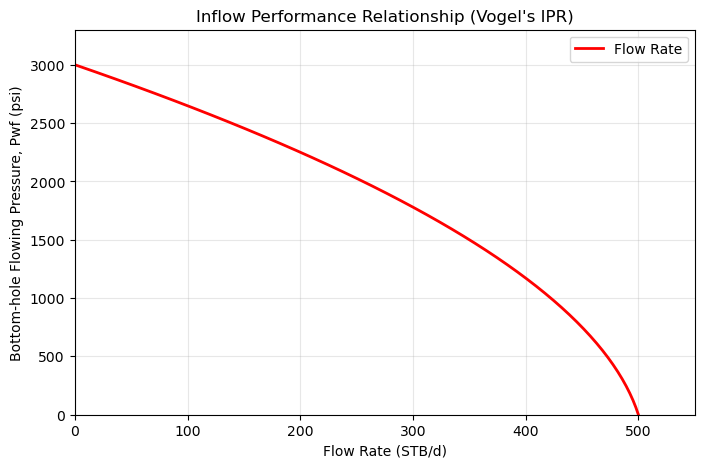

In [10]:
def vogel_ipr(pr, pwf_values, q_max):
    """
    Calculates flow rate (q) for given bottom-hole pressures using Vogel's IPR.

    Args:
        pr (float): Reservoir pressure (psi).
        pwf_values (list or array): Bottom-hole flowing pressures (psi).
        q_max (float): Absolute open flow potential (STB/d) at Pwf=0.

    Returns:
        list: Flow rates (q) corresponding to each Pwf.
    """
    q_rates = []   # Empty list
    for pwf in pwf_values:
        if pwf < 0:
            q_rates.append(q_max)  # Cannot flow below 0
        elif pwf >= pr:
            q_rates.append(0)  # No flow if Pwf >= Pr
        else:
            ratio = pwf / pr
            q = q_max * (1 - 0.2 * ratio - 0.8 * ratio**2)
            q_rates.append(q)
    return q_rates

# Generate data
pr_res = 3000  # psi
q_max_oil = 500  # STB/d
pwf_range = np.linspace(0, pr_res, 50)  # Array from 0 to Pr

# Calculate rates
q_rates_calculated = vogel_ipr(pr_res, pwf_range, q_max_oil)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(q_rates_calculated, pwf_range, 'r-', linewidth=2, label='Flow Rate')
plt.xlabel('Flow Rate (STB/d)')
plt.ylabel('Bottom-hole Flowing Pressure, Pwf (psi)')
plt.title('Inflow Performance Relationship (Vogel\'s IPR)')
plt.grid(True, alpha=0.3)
plt.ylim(0, pr_res*1.1)
plt.xlim(0, q_max_oil*1.1)
plt.legend()
plt.show()

#### Example 9: Geology/Geophysics - Density from Velocity using Gardner's Equation

 -  Formula: rho = a * Vp^b (Gardner's equation). Common values: a=0.31, b=0.25 for Vp in m/s, rho in g/cc.

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


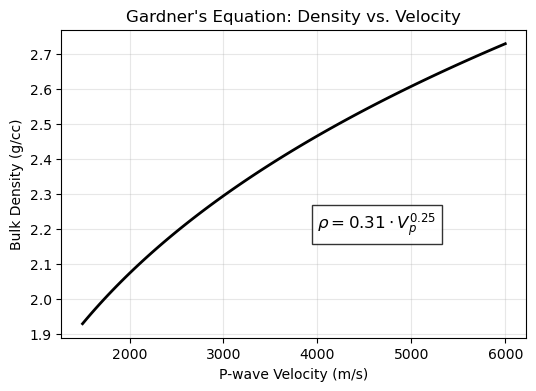

For Vp = 3500 m/s, estimated density = 2.38 g/cc


In [11]:
def gardner_density(vp, a=0.31, b=0.25):  # pre defined parameters
    """
    Estimates bulk density from P-wave velocity using Gardner's equation.

    Args:
        vp (float or array): P-wave velocity (m/s).
        a (float): Coefficient.
        b (float): Exponent.

    Returns:
        float or array: Estimated density (g/cc).
    """
    return a * (vp ** b)

# Generate a range of velocities
vp_values = np.linspace(1500, 6000, 100)  # m/s

# Calculate densities
rho_values = gardner_density(vp_values)

# Plotting
plt.figure(figsize=(6, 4))
plt.plot(vp_values, rho_values, 'k-', linewidth=2)
plt.xlabel('P-wave Velocity (m/s)')
plt.ylabel('Bulk Density (g/cc)')
plt.title('Gardner\'s Equation: Density vs. Velocity')
plt.grid(True, alpha=0.3)
plt.text(4000, 2.2, f'$\\rho = 0.31 \\cdot V_p^{{{0.25}}}$', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
plt.show()

# Example for a single value
vp_example = 3500
rho_example = gardner_density(vp_example)
print(f"For Vp = {vp_example} m/s, estimated density = {rho_example:.2f} g/cc")

#### Example 10: Petroleum Engineering/Geology - Material Balance Steady-State Depletion

 -  Formula: For a volumetric depletion drive reservoir (simplified): Np = (N * Boi / Bo) * (1 - Swi) * (cf + co) * (Pi - P)

In [ ]:
def calculate_oil_recovery(N, Boi, Bo, Swi, cf, co, Pi, P_current):
    """
    Calculates cumulative oil produced (Np) based on pressure drop.
    This is a highly simplified material balance for educational purposes.

    Args:
        N (float): Initial oil in place (STB).
        Boi (float): Initial oil formation volume factor.
        Bo (float): Oil FVF at current pressure.
        Swi (float): Initial water saturation.
        cf (float): Formation compressibility (psi^-1).
        co (float): Oil compressibility (psi^-1).
        Pi (float): Initial reservoir pressure (psi).
        P_current (float): Current reservoir pressure (psi).

    Returns:
        float: Cumulative oil produced (Np).
    """
    delta_P = Pi - P_current
    if delta_P <= 0:
        return 0.0  # No production if pressure hasn't dropped

    # Simplified from dV = V * c * dP
    # Np * Bo = N * Boi * (cf + co) * (Pi - P) / (1 - Swi)  (This is a very crude approximation!)
    # For teaching purposes, we'll use a more intuitive form:
    expansion_factor = (cf + co) * delta_P / (1 - Swi)
    Np = N * (Boi / Bo) * expansion_factor

    # Ensure Np is not negative and not more than N
    if Np < 0:
        Np = 0
    if Np > N:
        Np = N
    return Np

# Reservoir parameters
N_initial = 10e6  # 10 million STB
Boi_initial = 1.2
Bo_current = 1.25  # Increases as pressure drops
Swi_res = 0.20
cf_rock = 5e-6  # 1/psi
co_oil = 10e-6  # 1/psi
Pi_res = 4000  # psi

# Simulate production as pressure drops from 4000 to 3000 psi in steps
print("Pressure Depletion Recovery:")
print("Press (psi)\tCumulative Oil (STB)")
for P in range(4000, 2999, -100):  # Decrease by 100 psi each step
    Np_cum = calculate_oil_recovery(N_initial, Boi_initial, Bo_current, Swi_res, cf_rock, co_oil, Pi_res, P)
    print(f"{P}\t\t{Np_cum:.0f}")

print("\nNote: This is a simplified educational model, not a full material balance.")